# Experiment: CLIP ViT-L/14 + SwinV2-Base-Window12to16-192to256

This notebook trains a **local** detector using frozen CLIP image features and a lightweight trainable classifier head.

Pipeline:
1. Load train/test CSV + resolve image paths.
2. Use same split policy as before (`test_size=0.2`, `random_state=42`, stratified).
3. Extract frozen CLIP features.
4. Train a small linear/MLP head with epoch-wise validation F1.
5. Tune threshold for best validation F1.
6. Predict test set and export submission.

No ensemble is used in this notebook.


## 0. Install (if needed)


In [3]:
# !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install -q -U "transformers>=4.40" "huggingface_hub>=0.24" "huggingface_hub[hf_xet]" hf_xet pandas scikit-learn pillow matplotlib tqdm

# !pip install -q timm


## 1. Config


In [6]:
from pathlib import Path

# ===== Paths =====
PROJECT_DIR = Path.cwd()
TRAIN_CSV = PROJECT_DIR / "train.csv"
TEST_CSV = PROJECT_DIR / "test.csv"
IMAGES_DIR = PROJECT_DIR / "genai_image_challenge" / "images_final_sample"
OUTPUT_DIR = PROJECT_DIR / "artifacts_clip_vitl14"  # Reuse this folder across notebooks for shared CLIP artifacts
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== Split =====
SEED = 42
VAL_SIZE = 0.20

# ===== CLIP backbone =====
CLIP_MODEL_NAME = "openai/clip-vit-large-patch14"
MAX_CLIP_BATCH_SIZE = 32  # reduce if OOM
NUM_WORKERS = 0  # stable on Windows/Jupyter
USE_AMP = True

# ===== Linear probe head =====
HEAD_TYPE = "mlp"  # "linear" or "mlp"
HIDDEN_DIM = 256
DROPOUT = 0.2

EPOCHS = 30
BATCH_SIZE_HEAD = 256
LR = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0
EARLY_STOP_PATIENCE = 5

# ===== Test fallback =====
MISSING_TEST_DEFAULT = 0


## 2. Imports + Seed


In [9]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.std import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from transformers import CLIPModel, CLIPImageProcessor

# Force text-only behavior (no widget progress bars)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti with Max-Q Design


## 3. Load Data + Resolve Paths


In [11]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train label counts:\n", train_df["ground_truth"].value_counts().sort_index())


def resolve_path(image_id: str) -> str | None:
    image_id = str(image_id)
    candidates = [
        IMAGES_DIR / image_id,
        IMAGES_DIR / f"{image_id}.jpg",
        IMAGES_DIR / f"{image_id}.jpeg",
        IMAGES_DIR / f"{image_id}.png",
        IMAGES_DIR / f"{image_id}.webp",
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return None


train_df["path"] = train_df["image_id"].map(resolve_path)
test_df["path"] = test_df["image_id"].map(resolve_path)

train_missing = train_df["path"].isna().sum()
test_missing = test_df["path"].isna().sum()
print(f"Train missing images: {train_missing} / {len(train_df)}")
print(f"Test missing images : {test_missing} / {len(test_df)}")

train_df_avail = train_df.dropna(subset=["path"]).copy().reset_index(drop=True)
print("Train available shape:", train_df_avail.shape)


Train shape: (4800, 2)
Test shape: (2058, 1)
Train label counts:
 ground_truth
0    2485
1    2315
Name: count, dtype: int64
Train missing images: 0 / 4800
Test missing images : 0 / 2058
Train available shape: (4800, 3)


## 4. Same Split Policy as Existing Notebook


In [13]:
train_split, val_split = train_test_split(
    train_df_avail,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_df_avail["ground_truth"],
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print("Train split:", train_split.shape)
print("Val split  :", val_split.shape)
print("Train label counts:\n", train_split["ground_truth"].value_counts().sort_index())
print("Val label counts:\n", val_split["ground_truth"].value_counts().sort_index())


Train split: (3840, 3)
Val split  : (960, 3)
Train label counts:
 ground_truth
0    1988
1    1852
Name: count, dtype: int64
Val label counts:
 ground_truth
0    497
1    463
Name: count, dtype: int64


## 5. CLIP Feature Extractor (Frozen)


In [15]:
class CLIPImagePathDataset(Dataset):
    def __init__(self, df: pd.DataFrame, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.has_labels:
            return image, int(row["ground_truth"]), row["image_id"]
        return image, row["image_id"]


def collate_train(batch):
    images, labels, image_ids = zip(*batch)
    return list(images), torch.tensor(labels, dtype=torch.long), list(image_ids)


def collate_test(batch):
    images, image_ids = zip(*batch)
    return list(images), list(image_ids)


def _delete_clip_cache(repo_id: str):
    # Clears potentially corrupted cached shards for this model only.
    import shutil
    cache_root = Path.home() / ".cache" / "huggingface" / "hub"
    repo_key = f"models--{repo_id.replace('/', '--')}"
    if not cache_root.exists():
        return
    for d in cache_root.glob(f"{repo_key}*"):
        shutil.rmtree(d, ignore_errors=True)


def load_clip_robust(repo_id: str):
    last_err = None

    # 1) Standard load
    try:
        m = CLIPModel.from_pretrained(repo_id)
        p = CLIPImageProcessor.from_pretrained(repo_id)
        return m, p
    except Exception as e:
        last_err = e
        print("CLIP load attempt 1 failed:", repr(e))

    # 2) Force fresh HTTP download (bypass xet path if problematic)
    try:
        m = CLIPModel.from_pretrained(repo_id, force_download=True)
        p = CLIPImageProcessor.from_pretrained(repo_id, force_download=True)
        return m, p
    except Exception as e:
        last_err = e
        print("CLIP load attempt 2 failed:", repr(e))

    # 3) Clear model cache and retry
    try:
        _delete_clip_cache(repo_id)
        m = CLIPModel.from_pretrained(repo_id, force_download=True)
        p = CLIPImageProcessor.from_pretrained(repo_id, force_download=True)
        return m, p
    except Exception as e:
        last_err = e
        print("CLIP load attempt 3 failed:", repr(e))

    # 4) Final fallback: allow TF weights conversion path
    try:
        m = CLIPModel.from_pretrained(repo_id, from_tf=True, force_download=True)
        p = CLIPImageProcessor.from_pretrained(repo_id, force_download=True)
        return m, p
    except Exception as e:
        last_err = e
        print("CLIP load attempt 4 failed:", repr(e))

    raise RuntimeError(
        "Failed to load CLIP model after multiple retries. "
        "Try running the install cell with upgraded transformers/huggingface_hub and re-run."
    ) from last_err


clip_model, clip_processor = load_clip_robust(CLIP_MODEL_NAME)
clip_model = clip_model.to(DEVICE)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

print("Loaded CLIP:", CLIP_MODEL_NAME)


Loaded CLIP: openai/clip-vit-large-patch14


## 6. Extract and Cache Features
This runs CLIP in inference mode and saves feature arrays locally.


In [17]:
@torch.no_grad()
def extract_clip_features(df: pd.DataFrame, has_labels=True, desc="extract"):
    ds = CLIPImagePathDataset(df, has_labels=has_labels)
    loader = DataLoader(
        ds,
        batch_size=MAX_CLIP_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_train if has_labels else collate_test,
    )

    all_feats = []
    all_labels = []
    all_ids = []

    for batch in tqdm(loader, total=len(loader), desc=desc, ncols=100, ascii=True):
        if has_labels:
            images, labels, image_ids = batch
        else:
            images, image_ids = batch

        inputs = clip_processor(images=images, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            image_features = clip_model.get_image_features(pixel_values=pixel_values)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_feats.append(image_features.detach().cpu().float())
        all_ids.extend(image_ids)

        if has_labels:
            all_labels.append(labels)

    X = torch.cat(all_feats, dim=0)
    if has_labels:
        y = torch.cat(all_labels, dim=0)
        return X, y, all_ids
    return X, all_ids


train_feat_path = OUTPUT_DIR / "X_train_clip.pt"
train_label_path = OUTPUT_DIR / "y_train_clip.pt"
val_feat_path = OUTPUT_DIR / "X_val_clip.pt"
val_label_path = OUTPUT_DIR / "y_val_clip.pt"
test_feat_path = OUTPUT_DIR / "X_test_clip.pt"

if all(p.exists() for p in [train_feat_path, train_label_path, val_feat_path, val_label_path, test_feat_path]):
    print("Loading cached features...")
    X_train = torch.load(train_feat_path)
    y_train = torch.load(train_label_path)
    X_val = torch.load(val_feat_path)
    y_val = torch.load(val_label_path)
    X_test = torch.load(test_feat_path)

    test_avail_df = test_df.dropna(subset=["path"]).copy().reset_index(drop=True)
else:
    print("Extracting train split CLIP features...")
    X_train, y_train, _ = extract_clip_features(train_split, has_labels=True, desc="CLIP train")

    print("Extracting val split CLIP features...")
    X_val, y_val, _ = extract_clip_features(val_split, has_labels=True, desc="CLIP val")

    test_avail_df = test_df.dropna(subset=["path"]).copy().reset_index(drop=True)
    print("Extracting test CLIP features...")
    X_test, _ = extract_clip_features(test_avail_df, has_labels=False, desc="CLIP test")

    torch.save(X_train, train_feat_path)
    torch.save(y_train, train_label_path)
    torch.save(X_val, val_feat_path)
    torch.save(y_val, val_label_path)
    torch.save(X_test, test_feat_path)

print("Feature shapes:")
print("X_train:", tuple(X_train.shape), "y_train:", tuple(y_train.shape))
print("X_val  :", tuple(X_val.shape), "y_val  :", tuple(y_val.shape))
print("X_test :", tuple(X_test.shape))


Extracting train split CLIP features...


CLIP train: 100%|#################################################| 120/120 [39:39<00:00, 19.83s/it]


Extracting val split CLIP features...


CLIP val: 100%|#####################################################| 30/30 [09:56<00:00, 19.89s/it]


Extracting test CLIP features...


CLIP test: 100%|####################################################| 65/65 [21:20<00:00, 19.70s/it]

Feature shapes:
X_train: (3840, 768) y_train: (3840,)
X_val  : (960, 768) y_val  : (960,)
X_test : (2058, 768)


## 7. Trainable Head on Top of Frozen CLIP Features


In [19]:
feat_dim = X_train.shape[1]
print("CLIP feature dim:", feat_dim)

if HEAD_TYPE == "linear":
    head = nn.Linear(feat_dim, 2)
else:
    head = nn.Sequential(
        nn.Linear(feat_dim, HIDDEN_DIM),
        nn.GELU(),
        nn.Dropout(DROPOUT),
        nn.Linear(HIDDEN_DIM, 2),
    )

head = head.to(DEVICE)

# class weights
train_np = y_train.numpy()
counts = np.bincount(train_np, minlength=2)
class_weights = torch.tensor(
    [len(train_np) / (2.0 * max(1, c)) for c in counts],
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_ds_head = TensorDataset(X_train, y_train)
val_ds_head = TensorDataset(X_val, y_val)

train_loader_head = DataLoader(
    train_ds_head,
    batch_size=BATCH_SIZE_HEAD,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_loader_head = DataLoader(
    val_ds_head,
    batch_size=BATCH_SIZE_HEAD * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Head model:")
print(head)
print("Class weights:", class_weights.detach().cpu().numpy())


CLIP feature dim: 768
Head model:
Sequential(
  (0): Linear(in_features=768, out_features=256, bias=True)
  (1): GELU(approximate='none')
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=2, bias=True)
)
Class weights: [0.96579474 1.036717  ]


## 8. Training Loop (Epoch-wise Validation F1)


In [22]:
# Fallbacks in case function-definition cell was not executed in this session
if "eval_head" not in globals():
    @torch.no_grad()
    def eval_head(model, loader, criterion):
        model.eval()
        total_loss = 0.0
        probs_all = []
        targets_all = []

        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)[:, 1]

            total_loss += loss.item() * xb.size(0)
            probs_all.extend(probs.detach().cpu().numpy().tolist())
            targets_all.extend(yb.detach().cpu().numpy().tolist())

        avg_loss = total_loss / len(loader.dataset)
        probs_all = np.array(probs_all)
        targets_all = np.array(targets_all)
        preds_05 = (probs_all >= 0.5).astype(int)

        out = {
            "loss": avg_loss,
            "f1": f1_score(targets_all, preds_05),
            "precision": precision_score(targets_all, preds_05, zero_division=0),
            "recall": recall_score(targets_all, preds_05, zero_division=0),
        }
        return out, targets_all, probs_all

if "train_one_epoch_head" not in globals():
    def train_one_epoch_head(model, loader, criterion, optimizer, epoch):
        model.train()
        running_loss = 0.0
        pbar = tqdm(loader, total=len(loader), desc=f"Epoch {epoch} [head-train]", ncols=100, ascii=True)

        for xb, yb in pbar:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.2e}"})

        return running_loss / len(loader.dataset)

SKIP_CLIP_HEAD_TRAINING = True  # Reuse best_clip_head.pth from OUTPUT_DIR when available

best_f1 = -1.0
best_epoch = -1
no_improve = 0
history = []
best_ckpt_path = OUTPUT_DIR / "best_clip_head.pth"

if SKIP_CLIP_HEAD_TRAINING and best_ckpt_path.exists():
    print(f"Skipping CLIP head training. Using existing checkpoint: {best_ckpt_path}")
else:
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        train_loss = train_one_epoch_head(head, train_loader_head, criterion, optimizer, epoch)
        val_metrics, val_targets, val_probs = eval_head(head, val_loader_head, criterion)

        scheduler.step()

        elapsed = time.time() - t0
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_f1@0.5": val_metrics["f1"],
            "val_precision@0.5": val_metrics["precision"],
            "val_recall@0.5": val_metrics["recall"],
            "time_sec": elapsed,
        }
        history.append(row)

        improved = val_metrics["f1"] > best_f1
        if improved:
            best_f1 = val_metrics["f1"]
            best_epoch = epoch
            no_improve = 0
            torch.save(
                {
                    "head_state": head.state_dict(),
                    "best_f1": best_f1,
                    "best_epoch": best_epoch,
                    "config": {
                        "clip_model": CLIP_MODEL_NAME,
                        "head_type": HEAD_TYPE,
                        "seed": SEED,
                    },
                },
                best_ckpt_path,
            )
        else:
            no_improve += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_f1@0.5={val_metrics['f1']:.4f} | "
            f"best_f1={best_f1:.4f} (ep {best_epoch}) | "
            f"patience={no_improve}/{EARLY_STOP_PATIENCE} | "
            f"time={elapsed:.1f}s"
        )

        if improved:
            print(f"Saved best checkpoint -> {best_ckpt_path}")

        if no_improve >= EARLY_STOP_PATIENCE:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / "train_history_head.csv", index=False)
    print("Best epoch:", best_epoch, "Best val F1@0.5:", best_f1)


Epoch 1 [head-train]: 100%|###############| 15/15 [00:00<00:00, 39.97it/s, loss=0.6415, lr=1.00e-03]


Epoch 01 | train_loss=0.6705 | val_loss=0.6369 | val_f1@0.5=0.7487 | best_f1=0.7487 (ep 1) | patience=0/5 | time=0.4s
Saved best checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\best_clip_head.pth


Epoch 2 [head-train]: 100%|###############| 15/15 [00:00<00:00, 92.30it/s, loss=0.5737, lr=9.97e-04]


Epoch 02 | train_loss=0.6029 | val_loss=0.5535 | val_f1@0.5=0.7568 | best_f1=0.7568 (ep 2) | patience=0/5 | time=0.2s
Saved best checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\best_clip_head.pth


Epoch 3 [head-train]: 100%|##############| 15/15 [00:00<00:00, 128.16it/s, loss=0.4886, lr=9.89e-04]


...

Epoch 16 | train_loss=0.2668 | val_loss=0.3317 | val_f1@0.5=0.8559 | best_f1=0.8592 (ep 13) | patience=3/5 | time=0.1s


Epoch 17 [head-train]: 100%|#############| 15/15 [00:00<00:00, 142.14it/s, loss=0.2723, lr=4.48e-04]


Epoch 17 | train_loss=0.2653 | val_loss=0.3328 | val_f1@0.5=0.8538 | best_f1=0.8592 (ep 13) | patience=4/5 | time=0.1s


Epoch 18 [head-train]: 100%|#############| 15/15 [00:00<00:00, 140.82it/s, loss=0.2686, lr=3.96e-04]


Epoch 18 | train_loss=0.2633 | val_loss=0.3318 | val_f1@0.5=0.8547 | best_f1=0.8592 (ep 13) | patience=5/5 | time=0.1s
Early stopping triggered.
Best epoch: 13 Best val F1@0.5: 0.8592283628779979


## 9. Threshold Tuning on Validation


In [24]:
# Fallback in case eval_head cell was not executed in this session
if "eval_head" not in globals():
    @torch.no_grad()
    def eval_head(model, loader, criterion):
        model.eval()
        total_loss = 0.0
        probs_all = []
        targets_all = []

        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)[:, 1]

            total_loss += loss.item() * xb.size(0)
            probs_all.extend(probs.detach().cpu().numpy().tolist())
            targets_all.extend(yb.detach().cpu().numpy().tolist())

        avg_loss = total_loss / len(loader.dataset)
        probs_all = np.array(probs_all)
        targets_all = np.array(targets_all)
        preds_05 = (probs_all >= 0.5).astype(int)

        out = {
            "loss": avg_loss,
            "f1": f1_score(targets_all, preds_05),
            "precision": precision_score(targets_all, preds_05, zero_division=0),
            "recall": recall_score(targets_all, preds_05, zero_division=0),
        }
        return out, targets_all, probs_all

# Load best head checkpoint
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
head.load_state_dict(ckpt["head_state"])
head.eval()

val_metrics, val_targets, val_probs = eval_head(head, val_loader_head, criterion)

thresholds = np.linspace(0.05, 0.95, 181)
records = []
for th in thresholds:
    preds = (val_probs >= th).astype(int)
    records.append(
        {
            "threshold": th,
            "f1": f1_score(val_targets, preds),
            "precision": precision_score(val_targets, preds, zero_division=0),
            "recall": recall_score(val_targets, preds, zero_division=0),
        }
    )

thr_df = pd.DataFrame(records)
best_row = thr_df.sort_values("f1", ascending=False).iloc[0]
BEST_THRESHOLD = float(best_row["threshold"])

print("Best threshold:", BEST_THRESHOLD)
print(best_row)

thr_df.to_csv(OUTPUT_DIR / "threshold_search.csv", index=False)


Best threshold: 0.4549999999999999
threshold    0.455000
f1           0.860370
precision    0.819961
recall       0.904968
Name: 81, dtype: float64


## 10. Validation Report at Tuned Threshold


              precision    recall  f1-score   support

   Authentic       0.90      0.81      0.86       497
AI-Generated       0.82      0.90      0.86       463

    accuracy                           0.86       960
   macro avg       0.86      0.86      0.86       960
weighted avg       0.86      0.86      0.86       960

Precision: 0.8199608610567515
Recall   : 0.9049676025917927
F1       : 0.8603696098562629


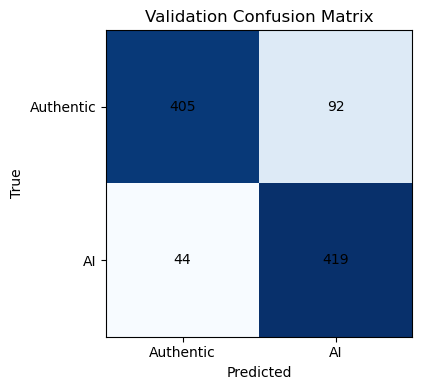

In [27]:
val_pred_best = (val_probs >= BEST_THRESHOLD).astype(int)

print(classification_report(val_targets, val_pred_best, target_names=["Authentic", "AI-Generated"]))
print("Precision:", precision_score(val_targets, val_pred_best, zero_division=0))
print("Recall   :", recall_score(val_targets, val_pred_best, zero_division=0))
print("F1       :", f1_score(val_targets, val_pred_best, zero_division=0))

cm = confusion_matrix(val_targets, val_pred_best)
fig, ax = plt.subplots(figsize=(4.5, 4.0))
ax.imshow(cm, cmap="Blues")
ax.set_title("Validation Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Authentic", "AI"])
ax.set_yticklabels(["Authentic", "AI"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()


## 11. Test Inference + Submission


In [ ]:
# Predict on extracted test features
head.eval()
with torch.no_grad():
    xb = X_test.to(DEVICE)
    logits = head(xb)
    prob_ai = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

pred_avail_df = test_avail_df[["image_id"]].copy()
pred_avail_df["prob_ai"] = prob_ai
pred_avail_df["prediction"] = (pred_avail_df["prob_ai"] >= BEST_THRESHOLD).astype(int)

# Merge to full test IDs and fill missing image IDs
submission = test_df[["image_id"]].merge(
    pred_avail_df[["image_id", "prediction", "prob_ai"]],
    on="image_id",
    how="left",
)

missing_mask = submission["prediction"].isna()
if missing_mask.any():
    submission.loc[missing_mask, "prediction"] = int(MISSING_TEST_DEFAULT)
    submission.loc[missing_mask, "prob_ai"] = np.nan

submission["prediction"] = submission["prediction"].astype(int)

print("Pred distribution:\n", submission["prediction"].value_counts().sort_index())
print("Missing-image fallback rows:", int(missing_mask.sum()))

submission_out = submission[["image_id", "prediction"]]
submission_out.to_csv(OUTPUT_DIR / "submission_clip_vitl14_linear_probe.csv", index=False)
submission.to_csv(OUTPUT_DIR / "submission_clip_vitl14_with_probs.csv", index=False)

print("Saved:")
print(" -", OUTPUT_DIR / "submission_clip_vitl14_linear_probe.csv")
print(" -", OUTPUT_DIR / "submission_clip_vitl14_with_probs.csv")
submission_out.head()


## 12. Optional: Save Split and Val Predictions


In [29]:
train_split[["image_id", "ground_truth", "path"]].to_csv(OUTPUT_DIR / "train_split_seed42.csv", index=False)
val_split[["image_id", "ground_truth", "path"]].to_csv(OUTPUT_DIR / "val_split_seed42.csv", index=False)

val_pred_df = val_split[["image_id", "ground_truth"]].copy()
val_pred_df["prob_ai"] = val_probs
val_pred_df["pred_0p5"] = (val_probs >= 0.5).astype(int)
val_pred_df["pred_best_th"] = (val_probs >= BEST_THRESHOLD).astype(int)
val_pred_df.to_csv(OUTPUT_DIR / "val_predictions.csv", index=False)

print("Saved reproducibility artifacts to:", OUTPUT_DIR)


Saved reproducibility artifacts to: D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14


## 13. swinv2_base_window12to16_192to256 Fine-Tuning (Image Model)
Run this after CLIP training if you want a second model in the same notebook.
This section logs **F1 after each epoch** on validation.


In [32]:
import timm
from timm.data import create_transform
from torch.utils.data import Dataset, DataLoader

# ConvNeXt config
CN_BACKBONE = "swinv2_base_window12to16_192to256"
CN_IMG_SIZE = 256
CN_BATCH_SIZE = 4
CN_ACCUM_STEPS = 2
CN_EPOCHS = 14
CN_LR = 1e-4
CN_WEIGHT_DECAY = 1e-4
CN_LABEL_SMOOTHING = 0.03
CN_EARLY_STOP_PATIENCE = 4
CN_NUM_WORKERS = 0
CN_MIXED_PRECISION = True

CN_OUTPUT_DIR = OUTPUT_DIR / "swinv2_base_window12to16_192to256_track"
CN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ConvNeXt config ready.")


ConvNeXt config ready.


In [33]:
class EtsyImageDataset(Dataset):
    def __init__(self, df, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        if self.has_labels:
            return img, int(row["ground_truth"]), row["image_id"]
        return img, row["image_id"]


cn_train_tf = create_transform(
    input_size=(3, CN_IMG_SIZE, CN_IMG_SIZE),
    is_training=True,
    auto_augment="rand-m7-mstd0.5-inc1",
    re_prob=0.15,
    re_mode="pixel",
    interpolation="bicubic",
)
cn_val_tf = create_transform(
    input_size=(3, CN_IMG_SIZE, CN_IMG_SIZE),
    is_training=False,
    interpolation="bicubic",
)

cn_train_ds = EtsyImageDataset(train_split, transform=cn_train_tf, has_labels=True)
cn_val_ds = EtsyImageDataset(val_split, transform=cn_val_tf, has_labels=True)
cn_test_ds = EtsyImageDataset(test_avail_df, transform=cn_val_tf, has_labels=False)

cn_train_loader = DataLoader(cn_train_ds, batch_size=CN_BATCH_SIZE, shuffle=True, num_workers=CN_NUM_WORKERS, pin_memory=True, drop_last=True)
cn_val_loader = DataLoader(cn_val_ds, batch_size=CN_BATCH_SIZE*2, shuffle=False, num_workers=CN_NUM_WORKERS, pin_memory=True)
cn_test_loader = DataLoader(cn_test_ds, batch_size=CN_BATCH_SIZE*2, shuffle=False, num_workers=CN_NUM_WORKERS, pin_memory=True)

print("CN loaders:", len(cn_train_loader), len(cn_val_loader), len(cn_test_loader))


CN loaders: 960 120 258


In [36]:
cn_model = timm.create_model(CN_BACKBONE, pretrained=True, num_classes=2).to(DEVICE)

cn_counts = train_split["ground_truth"].value_counts().sort_index().values
cn_class_weights = torch.tensor([len(train_split)/(2.0*c) for c in cn_counts], dtype=torch.float32, device=DEVICE)

cn_criterion = nn.CrossEntropyLoss(weight=cn_class_weights, label_smoothing=CN_LABEL_SMOOTHING)
cn_optimizer = torch.optim.AdamW(cn_model.parameters(), lr=CN_LR, weight_decay=CN_WEIGHT_DECAY)

cn_steps_per_epoch = max(1, len(cn_train_loader) // CN_ACCUM_STEPS)
cn_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    cn_optimizer,
    max_lr=CN_LR,
    total_steps=max(1, CN_EPOCHS * cn_steps_per_epoch),
    pct_start=0.15,
    anneal_strategy="cos",
)

cn_scaler = torch.cuda.amp.GradScaler(enabled=(CN_MIXED_PRECISION and DEVICE.type=="cuda"))
cn_ckpt = CN_OUTPUT_DIR / f"best_{CN_BACKBONE}.pth"

print("CN model params (M):", sum(p.numel() for p in cn_model.parameters())/1e6)


CN model params (M): 86.895866


In [38]:
@torch.no_grad()
def cn_eval(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    probs_all, y_all, id_all = [], [], []

    for batch in loader:
        images, y, image_ids = batch
        images = images.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(CN_MIXED_PRECISION and DEVICE.type=="cuda")):
            logits = model(images)
            loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)[:,1]
        loss_sum += loss.item() * images.size(0)
        probs_all.extend(probs.detach().cpu().numpy().tolist())
        y_all.extend(y.detach().cpu().numpy().tolist())
        id_all.extend(image_ids)

    avg_loss = loss_sum / len(loader.dataset)
    probs_all = np.array(probs_all)
    y_all = np.array(y_all)
    pred_05 = (probs_all >= 0.5).astype(int)

    metrics = {
        "loss": avg_loss,
        "f1": f1_score(y_all, pred_05),
        "precision": precision_score(y_all, pred_05, zero_division=0),
        "recall": recall_score(y_all, pred_05, zero_division=0),
    }
    return metrics, y_all, probs_all, id_all


def cn_train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, epoch):
    model.train()
    run_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"{CN_BACKBONE} Epoch {epoch}", ncols=100, ascii=True)
    for step, (images, y, _) in pbar:
        images = images.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(CN_MIXED_PRECISION and DEVICE.type=="cuda")):
            logits = model(images)
            loss = criterion(logits, y) / CN_ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % CN_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        run_loss += loss.item() * CN_ACCUM_STEPS * images.size(0)
        pbar.set_postfix({"loss": f"{loss.item()*CN_ACCUM_STEPS:.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.2e}"})

    return run_loss / len(loader.dataset)


In [40]:
cn_best_f1 = -1.0
cn_best_epoch = -1
cn_no_improve = 0
cn_hist = []

for ep in range(1, CN_EPOCHS + 1):
    t0 = time.time()

    cn_train_loss = cn_train_one_epoch(cn_model, cn_train_loader, cn_criterion, cn_optimizer, cn_scheduler, cn_scaler, ep)
    cn_val_metrics, cn_val_y, cn_val_probs, cn_val_ids = cn_eval(cn_model, cn_val_loader, cn_criterion)

    elapsed = time.time() - t0
    cn_hist.append({
        "epoch": ep,
        "train_loss": cn_train_loss,
        "val_loss": cn_val_metrics["loss"],
        "val_f1@0.5": cn_val_metrics["f1"],
        "val_precision@0.5": cn_val_metrics["precision"],
        "val_recall@0.5": cn_val_metrics["recall"],
        "time_sec": elapsed,
    })

    improved = cn_val_metrics["f1"] > cn_best_f1
    if improved:
        cn_best_f1 = cn_val_metrics["f1"]
        cn_best_epoch = ep
        cn_no_improve = 0
        torch.save({
            "model_state": cn_model.state_dict(),
            "best_f1": cn_best_f1,
            "best_epoch": cn_best_epoch,
            "config": {"backbone": CN_BACKBONE, "img_size": CN_IMG_SIZE, "seed": SEED},
        }, cn_ckpt)
        print(f"Saved best image-model checkpoint -> {cn_ckpt}")
    else:
        cn_no_improve += 1

    print(
        f"{CN_BACKBONE} Epoch {ep:02d} | train_loss={cn_train_loss:.4f} | val_loss={cn_val_metrics['loss']:.4f} | "
        f"val_f1@0.5={cn_val_metrics['f1']:.4f} | best_f1={cn_best_f1:.4f} (ep {cn_best_epoch}) | "
        f"patience={cn_no_improve}/{CN_EARLY_STOP_PATIENCE} | time={elapsed:.1f}s"
    )

    if cn_no_improve >= CN_EARLY_STOP_PATIENCE:
        print("Image-model early stopping triggered.")
        break

pd.DataFrame(cn_hist).to_csv(CN_OUTPUT_DIR / "train_history_convnext.csv", index=False)
print("swinv2_base_window12to16_192to256 best epoch:", cn_best_epoch, "swinv2_base_window12to16_192to256 best F1@0.5:", cn_best_f1)


swinv2_base_window12to16_192to256 Epoch 1: 100%|#| 960/960 [39:52<00:00,  2.49s/it, loss=0.4958, lr=


Saved best image-model checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\swinv2_base_window12to16_192to256_track\best_swinv2_base_window12to16_192to256.pth
swinv2_base_window12to16_192to256 Epoch 01 | train_loss=0.5336 | val_loss=0.4027 | val_f1@0.5=0.8252 | best_f1=0.8252 (ep 1) | patience=0/4 | time=2600.4s


swinv2_base_window12to16_192to256 Epoch 2: 100%|#| 960/960 [39:07<00:00,  2.45s/it, loss=0.4695, lr=


swinv2_base_window12to16_192to256 Epoch 02 | train_loss=0.4941 | val_loss=0.4484 | val_f1@0.5=0.8139 | best_f1=0.8252 (ep 1) | patience=1/4 | time=2550.6s


swinv2_base_window12to16_192to256 Epoch 3: 100%|#| 960/960 [39:31<00:00,  2.47s/it, loss=0.3430, lr=


...

Saved best image-model checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\swinv2_base_window12to16_192to256_track\best_swinv2_base_window12to16_192to256.pth
swinv2_base_window12to16_192to256 Epoch 12 | train_loss=0.1287 | val_loss=0.2821 | val_f1@0.5=0.9198 | best_f1=0.9198 (ep 12) | patience=0/4 | time=2571.0s


swinv2_base_window12to16_192to256 Epoch 13: 100%|#| 960/960 [39:06<00:00,  2.44s/it, loss=0.0761, lr


Saved best image-model checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\swinv2_base_window12to16_192to256_track\best_swinv2_base_window12to16_192to256.pth
swinv2_base_window12to16_192to256 Epoch 13 | train_loss=0.1205 | val_loss=0.2682 | val_f1@0.5=0.9241 | best_f1=0.9241 (ep 13) | patience=0/4 | time=2545.8s


swinv2_base_window12to16_192to256 Epoch 14: 100%|#| 960/960 [39:11<00:00,  2.45s/it, loss=0.0791, lr


Saved best image-model checkpoint -> D:\AI\[External] DCU 2026 ML challenge - external\artifacts_clip_vitl14\swinv2_base_window12to16_192to256_track\best_swinv2_base_window12to16_192to256.pth
swinv2_base_window12to16_192to256 Epoch 14 | train_loss=0.1181 | val_loss=0.2609 | val_f1@0.5=0.9275 | best_f1=0.9275 (ep 14) | patience=0/4 | time=2551.3s
swinv2_base_window12to16_192to256 best epoch: 14 swinv2_base_window12to16_192to256 best F1@0.5: 0.9275053304904051


## 14. swinv2_base_window12to16_192to256 Threshold Tuning + Validation Report


In [42]:
cn_ck = torch.load(cn_ckpt, map_location=DEVICE)
cn_model.load_state_dict(cn_ck["model_state"])
cn_model.eval()

cn_val_metrics, cn_val_y, cn_val_probs, cn_val_ids = cn_eval(cn_model, cn_val_loader, cn_criterion)

cn_thr_records = []
for th in np.linspace(0.05, 0.95, 181):
    pred = (cn_val_probs >= th).astype(int)
    cn_thr_records.append({
        "threshold": th,
        "f1": f1_score(cn_val_y, pred),
        "precision": precision_score(cn_val_y, pred, zero_division=0),
        "recall": recall_score(cn_val_y, pred, zero_division=0),
    })

cn_thr_df = pd.DataFrame(cn_thr_records)
cn_best_row = cn_thr_df.sort_values("f1", ascending=False).iloc[0]
CN_BEST_THRESHOLD = float(cn_best_row["threshold"])

cn_pred_best = (cn_val_probs >= CN_BEST_THRESHOLD).astype(int)
print("swinv2_base_window12to16_192to256 best threshold:", CN_BEST_THRESHOLD)
print(cn_best_row)
print(classification_report(cn_val_y, cn_pred_best, target_names=["Authentic","AI-Generated"]))

cn_thr_df.to_csv(CN_OUTPUT_DIR / "threshold_search_convnext.csv", index=False)


swinv2_base_window12to16_192to256 best threshold: 0.74
threshold    0.740000
f1           0.929117
precision    0.938326
recall       0.920086
Name: 138, dtype: float64
              precision    recall  f1-score   support

   Authentic       0.93      0.94      0.94       497
AI-Generated       0.94      0.92      0.93       463

    accuracy                           0.93       960
   macro avg       0.93      0.93      0.93       960
weighted avg       0.93      0.93      0.93       960



## 15. CLIP + swinv2_base_window12to16_192to256 Combined Validation Evaluation
This combines probabilities and finds best alpha + threshold on validation.
`combined_prob = alpha * convnext_prob + (1-alpha) * clip_prob`


In [44]:
# Ensure CLIP best head is loaded
clip_ck = torch.load(OUTPUT_DIR / "best_clip_head.pth", map_location=DEVICE)
head.load_state_dict(clip_ck["head_state"])
head.eval()

# Recompute CLIP val probabilities from cached X_val
with torch.no_grad():
    logits_clip_val = head(X_val.to(DEVICE))
    clip_val_probs = torch.softmax(logits_clip_val, dim=1)[:,1].detach().cpu().numpy()

# ConvNeXt val probabilities already computed in previous section: cn_val_probs
assert len(clip_val_probs) == len(cn_val_probs) == len(cn_val_y)

# Optional sanity check on order alignment via image_id
val_ids_from_split = val_split["image_id"].tolist()
if list(cn_val_ids) != val_ids_from_split:
    print("Warning: val id order mismatch detected; aligning by image_id.")
    cn_df = pd.DataFrame({"image_id": cn_val_ids, "cn_prob": cn_val_probs})
    clip_df = pd.DataFrame({"image_id": val_ids_from_split, "clip_prob": clip_val_probs, "y": cn_val_y})
    m = clip_df.merge(cn_df, on="image_id", how="inner")
    y_true = m["y"].to_numpy()
    clip_probs_aligned = m["clip_prob"].to_numpy()
    cn_probs_aligned = m["cn_prob"].to_numpy()
else:
    y_true = cn_val_y
    clip_probs_aligned = clip_val_probs
    cn_probs_aligned = cn_val_probs

best_combo = {"f1": -1.0, "alpha": None, "threshold": None, "precision": None, "recall": None}
for alpha in np.linspace(0.0, 1.0, 21):
    combo = alpha * cn_probs_aligned + (1.0 - alpha) * clip_probs_aligned
    for th in np.linspace(0.05, 0.95, 181):
        pred = (combo >= th).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_combo["f1"]:
            best_combo = {
                "f1": float(f1),
                "alpha": float(alpha),
                "threshold": float(th),
                "precision": float(precision_score(y_true, pred, zero_division=0)),
                "recall": float(recall_score(y_true, pred, zero_division=0)),
            }

print("Best combined result:")
print(best_combo)
print(f"CLIP tuned F1 (earlier)    : {float(best_row['f1']):.4f}")
print(f"swinv2_base_window12to16_192to256 tuned F1          : {float(cn_best_row['f1']):.4f}")
print(f"Combined tuned F1          : {best_combo['f1']:.4f}")


Best combined result:
{'f1': 0.9424538545059717, 'alpha': 0.5, 'threshold': 0.5349999999999999, 'precision': 0.9475982532751092, 'recall': 0.937365010799136}
CLIP tuned F1 (earlier)    : 0.8604
swinv2_base_window12to16_192to256 tuned F1          : 0.9291
Combined tuned F1          : 0.9425


## 16. Optional Combined Test Submission
Run this after section 15 to export a combined model submission.


In [ ]:
# CLIP test probs from cached X_test
with torch.no_grad():
    logits_clip_test = head(X_test.to(DEVICE))
    clip_test_probs = torch.softmax(logits_clip_test, dim=1)[:,1].detach().cpu().numpy()

# ConvNeXt test probs
@torch.no_grad()
def cn_predict_test_probs(model, loader):
    model.eval()
    ids, probs = [], []
    for images, image_ids in tqdm(loader, total=len(loader), desc="swinv2_base_window12to16_192to256 test", ncols=100, ascii=True):
        images = images.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(CN_MIXED_PRECISION and DEVICE.type=="cuda")):
            logits = model(images)
            p = torch.softmax(logits, dim=1)[:,1]
        probs.extend(p.detach().cpu().numpy().tolist())
        ids.extend(image_ids)
    return pd.DataFrame({"image_id": ids, "cn_prob": probs})

cn_test_df = cn_predict_test_probs(cn_model, cn_test_loader)
clip_test_df = pd.DataFrame({"image_id": test_avail_df["image_id"].tolist(), "clip_prob": clip_test_probs})
combo_df = clip_test_df.merge(cn_test_df, on="image_id", how="inner")

alpha = best_combo["alpha"]
th = best_combo["threshold"]
combo_df["prob_ai"] = alpha * combo_df["cn_prob"] + (1-alpha) * combo_df["clip_prob"]
combo_df["prediction"] = (combo_df["prob_ai"] >= th).astype(int)

submission_combo = test_df[["image_id"]].merge(combo_df[["image_id", "prediction", "prob_ai"]], on="image_id", how="left")
miss = submission_combo["prediction"].isna()
if miss.any():
    submission_combo.loc[miss, "prediction"] = int(MISSING_TEST_DEFAULT)
submission_combo["prediction"] = submission_combo["prediction"].astype(int)

submission_combo[["image_id","prediction"]].to_csv(OUTPUT_DIR / "submission_clip_swinv2_base_window12to16_192to256_combo.csv", index=False)
submission_combo.to_csv(OUTPUT_DIR / "submission_clip_swinv2_base_window12to16_192to256_combo_with_probs.csv", index=False)

print("Saved combined submissions to:", OUTPUT_DIR)
print("Missing fallback rows:", int(miss.sum()))
print(submission_combo["prediction"].value_counts().sort_index())
